<a href="https://colab.research.google.com/github/Anusha3104/AI_ML_intership/blob/main/customersegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler#Used to normalize the data before clustering.

In [4]:
df = pd.read_excel("/content/sample_data/Online Retail.xlsx")

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
df.isnull().sum()#it counts the missing values

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [12]:
df["Description"]= df["Description"].fillna(df["Description"].mode())

In [13]:
df=df.dropna(subset=['CustomerID'])

In [14]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [15]:
df['Amount'] = df['Quantity'] * df['UnitPrice']

In [16]:
customer_details = df.groupby('CustomerID').agg({
    'Quantity':'sum',
    'UnitPrice':'mean',
    'Amount':'sum'
}).reset_index()

In [17]:
x = customer_details[['Quantity','UnitPrice','Amount']]

In [18]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [20]:
wcss = []#Creates an empty list.It will store the WCSS for each value of K.

In [25]:

wcss=[]
for i in range(1,11):
  model=KMeans(n_clusters=i, random_state=10)

  model.fit(x_scaled)
  wcss.append(model.inertia_)

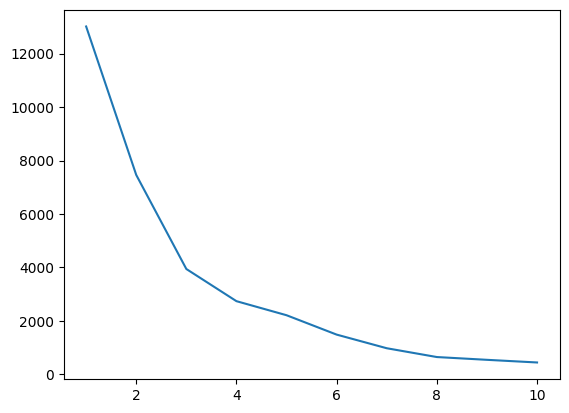

In [26]:
plt.plot(range(1,11), wcss)